## **Sentiment Analysis on Amazon Product Reviews**

### **Project Objective**

The objective of this project is to perform sentiment prediction on product reviews using Natural Language Processing(NLP).

A labeled dataset containing review text and sentiment categories is used to train machine learning models.  
The trained model learns patterns from the text and predicts the sentiment reviews.

## Dataset Description

The dataset contains product reviews and their corresponding sentiment labels.

Columns in dataset:

- sentiments → sentiment label (positive / negative / neutral)
- review → cleaned text review
- cleaned_review_length → length of review
- review_score → rating score

Total rows ≈ 17,000+

Only the following columns are used in this project:

- review
- sentiments

Required libraries for data preprocessing, NLP and machine learning are imported.

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report,precision_score
import re
import string
from sklearn.preprocessing import LabelEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud

In [26]:
df = pd.read_csv("cleaned_reviews.csv")

In [27]:
df.head()

,sentiments,cleaned_review,cleaned_review_length,review_score
0,positive,i wish would have gotten one earlier love it a...,19,5.0
1,neutral,i ve learned this lesson again open the packag...,88,1.0
2,neutral,it is so slow and lags find better option,9,2.0
3,neutral,roller ball stopped working within months of m...,12,1.0
4,neutral,i like the color and size but it few days out ...,21,1.0


In [28]:
df.tail()

,sentiments,cleaned_review,cleaned_review_length,review_score
17335,positive,i love this speaker and love can take it anywh...,30,5.0
17336,positive,i use it in my house easy to connect and loud ...,13,4.0
17337,positive,the bass is good and the battery is amazing mu...,41,5.0
17338,positive,love it,2,5.0
17339,neutral,mono speaker,2,5.0


In [29]:
df.shape

(17340, 4)

In [30]:
df.columns

Index(['sentiments', 'cleaned_review', 'cleaned_review_length',
       'review_score'],
      dtype='object')

In [31]:
df.isnull().sum()

sentiments               0
cleaned_review           3
cleaned_review_length    0
review_score             0
dtype: int64

In [32]:
df = df.dropna(subset=['cleaned_review'])

In [33]:
df.isnull().sum()

sentiments               0
cleaned_review           0
cleaned_review_length    0
review_score             0
dtype: int64

In [34]:
df = df.drop(['cleaned_review_length',
       'review_score'],axis=1)
df = df.rename(columns={'cleaned_review': 'review'})
df.head()

,sentiments,review
0,positive,i wish would have gotten one earlier love it a...
1,neutral,i ve learned this lesson again open the packag...
2,neutral,it is so slow and lags find better option
3,neutral,roller ball stopped working within months of m...
4,neutral,i like the color and size but it few days out ...


In [36]:
encoder = LabelEncoder()
df['sentiments'] = encoder.fit_transform(df['sentiments'])
df.head()

,sentiments,review
0,2,i wish would have gotten one earlier love it a...
1,1,i ve learned this lesson again open the packag...
2,1,it is so slow and lags find better option
3,1,roller ball stopped working within months of m...
4,1,i like the color and size but it few days out ...


### Text(review) Preprocessing

Raw text data contains noise such as symbols, numbers, and links.
Machine learning models cannot understand raw text directly.

Preprocessing helps to:

- reduce noise
- standardize text
- improve model accuracy
- make vectorization easier

In [39]:
def wordopt(review):
    review=review.lower()
    review=re.sub('\[.*?\]','',review)
    review=re.sub("\\W"," ",review)
    review=re.sub('https?://\S+|www\.\S+','',review)
    review=re.sub('<.*?>+','',review)
    review=re.sub('[%s]'% re.escape(string.punctuation),'',review)
    review=re.sub('\n','',review)
    review=re.sub('\w*\d\w*','',review)
    return review

In [40]:
df["review"]=df["review"].apply(wordopt)
df

,sentiments,review
0,2,i wish would have gotten one earlier love it a...
1,1,i ve learned this lesson again open the packag...
2,1,it is so slow and lags find better option
3,1,roller ball stopped working within months of m...
4,1,i like the color and size but it few days out ...
...,...,...
17335,2,i love this speaker and love can take it anywh...
17336,2,i use it in my house easy to connect and loud ...
17337,2,the bass is good and the battery is amazing mu...
17338,2,love it


### WordCloud Visualization of Review Text

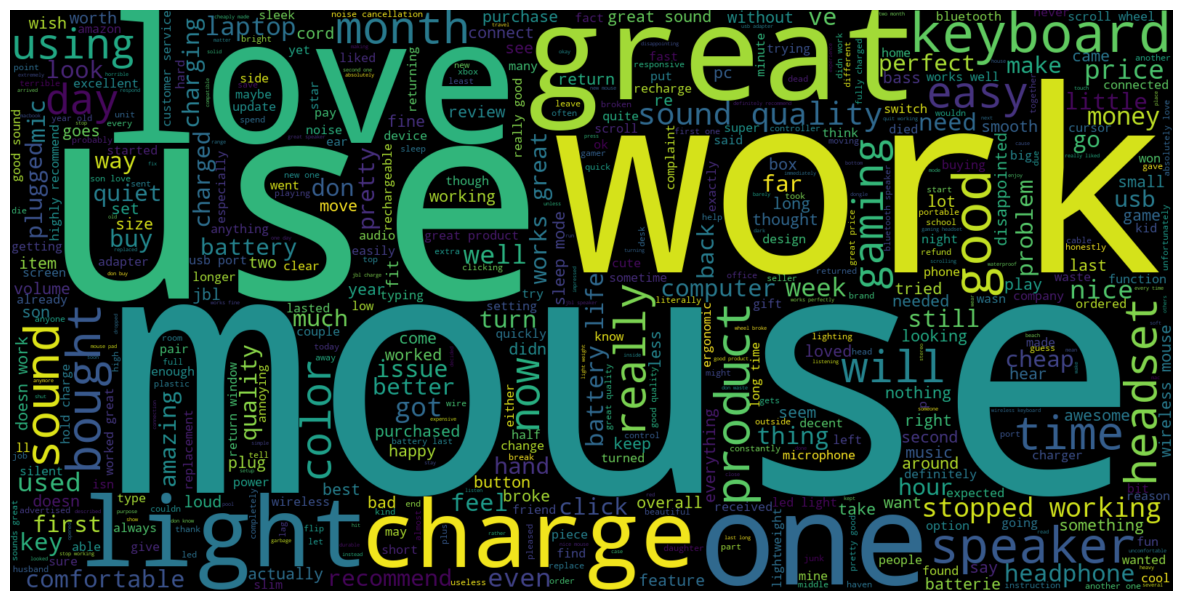

In [42]:
review=' '.join([word for word in df['review']])
plt.figure(figsize=(15,10),facecolor='None')
wordcloud=WordCloud(max_words=500,width=1600,height=800).generate(review)
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis("off")
plt.show()

In [43]:
x=df['review']
y=df['sentiments']

In [44]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [45]:
vectorization=TfidfVectorizer()
xv_train=vectorization.fit_transform(x_train) 
xv_test=vectorization.transform(x_test)

In [46]:
xv_train.shape

(13002, 8632)

In [47]:
xv_test.shape

(4335, 8632)

### Model Training, Evaluation and Comparison

In [48]:
LR=LogisticRegression()
LR.fit(xv_train,y_train)

pred_lr1=LR.predict(xv_test)
pred_lr1

print(accuracy_score(y_test,pred_lr1))

0.8295271049596309


In [50]:
SVM=SVC(kernel='rbf')
svm_clf= SVC(random_state=42)
svm_model=svm_clf.fit(xv_train,y_train)

y_pred_svm1=svm_model.predict(xv_test)
y_pred_svm1

print(accuracy_score(y_test,y_pred_svm1))

0.8742791234140715


In [51]:
RF= RandomForestClassifier(random_state=42)
RF_model=RF.fit(xv_train,y_train)

y_pred_RF1=RF_model.predict(xv_test)
y_pred_RF1

print(accuracy_score(y_test,y_pred_RF1))

0.8491349480968858


In [52]:
pt=[]
for i in[LR,SVM,RF]:
    i.fit(xv_train,y_train)
    pt.append(round(accuracy_score(y_test,i.predict(xv_test))*100,2))
print(pt)

[82.95, 87.43, 84.91]


Among the three models SVM achieved the highest accuracy (87.43) and performed better than Logistic Regression and Random Forest.

In [53]:
pd.set_option('display.max_colwidth', None)

In [60]:
x.head()

0                                                                                                                                                                                                                                                                                                                                                                                   i wish would have gotten one earlier love it and it makes working in my laptop so much easier
1    i ve learned this lesson again open the package and use the product right away ordered this mouse in august as my travel mouse and just packed it away in my bag now ve been visiting family in the pnw since mid september the mouse took charge and worked fine for couple of weeks after recharged the mouse it worked for day or two and then ceased to function the optical light will flash once when turned on then nothing of course the return window is well past 
2                                                                   

In [61]:
y.head()

0    2
1    1
2    1
3    1
4    1
Name: sentiments, dtype: int64

### Model Prediction

In [64]:
example = ['''i wish would have gotten one earlier love it and it makes working in my laptop so much easier''']
example_vectorized = vectorization.transform(example)
result = LR.predict(example_vectorized)

print(result)
print(encoder.inverse_transform(result))

[2]
['positive']


In [63]:
example = ['''i like the color and size but it few days out of the return period and it will not hold charge''']
example_vectorized = vectorization.transform(example)
result = LR.predict(example_vectorized)

print(result)
print(encoder.inverse_transform(result))

[1]
['neutral']


Sample reviews from the dataset are used to verify the correctness of model predictions.  
The model predicted the correct sentiment for the selected samples.

### Sentiment Prediction on New Reviews

In [73]:
example = ["this product is very useful and easy to use","this product is very bad and not working","product is ok not bad not great"]
result = SVM.predict(vectorization.transform(example))
print(result)
print(encoder.inverse_transform(result))

[2 0 1]
['positive' 'negative' 'neutral']


## **Conclusion**

In this project sentiment analysis was performed on Amazon product reviews using Natural Language Processing (NLP) techniques.

The text data was preprocessed and converted into numerical form using TF-IDF vectorization.  
Multiple machine learning models such as Logistic Regression, Support Vector Machine and Random Forest were trained and evaluated.

Among the models Support Vector Machine (SVM) achieved the highest accuracy and performed better than the other models.

The trained model was tested on sample reviews as well as new reviews, and it successfully predicted positive, negative and neutral sentiments.

This project demonstrates how NLP and machine learning can be used for real-world text classification problems.